In [1]:
import numpy as np
import pandas as pd
import os
import pathlib
from scipy.stats import gaussian_kde
from tqdm import tqdm
import warnings
import seaborn as sns
from skimage import util
from skimage.filters import threshold_otsu, gaussian, threshold_isodata, threshold_minimum, threshold_triangle, threshold_otsu, threshold_mean, threshold_li, try_all_threshold, threshold_yen
from skimage.segmentation import clear_border, watershed
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, opening, ball, dilation, erosion
from skimage.transform import rescale
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from scipy import stats as _stats
from matplotlib.colors import to_hex
from skimage.filters import median as median_filter
from skimage.morphology import square
from tifffile import imread
import tifffile
import liffile
import napari
import colorsys
from collections import defaultdict
from skimage.morphology import closing, disk

from PIL import ImageColor
warnings.filterwarnings("ignore")

In [2]:
def create_n_valued_palette(base_colour_hex, n=5):
    r, g, b = ImageColor.getcolor(base_colour_hex, "RGB")
    r, g, b = r/255, g/255, b/255
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    adjustments = np.linspace(0.5, 1.4, n)
    palette = []
    for a in adjustments:
        l_adj = min(max(l * a, 0), 1)
        rgb = colorsys.hls_to_rgb(h, l_adj, s)
        palette.append(to_hex(rgb))
    return palette

# Default palette: add/change entries here to introduce new groups
DEFAULT_PALETTE = {
    "ARi": "#ff0000",
    "UTD": "#1e90ff",
}

In [3]:
def add_experiment_info(df):
    name = str(df["image"]).lower() + str(df["lif_file"]).lower()
    if "fl32" in name:
        df["patient"] = "fl32"
    elif "fl12" in name:
        df["patient"] = "fl12"
    else:
        df["patient"] = "unknown"
    if "day6" in name:
        df["day"] = "6"
    elif "day7" in name:
        df["day"] = "7"
    else:
        df["day"] = "unknown"

    return df

In [4]:
# Canonical regions used throughout
REGIONS = ["chip", "not_chip", "tumour", "chip_not_tumour",
           "chip_vasculature", "chip_not_vasculature", "left", "right"]

def count_cells(region_mask, crow, ccol):
    """Count how many cell centroids (crow, ccol) fall inside region_mask."""
    if len(crow) == 0:
        return 0
    return int(region_mask[crow, ccol].sum())


In [5]:
# ── QC figure: show segmented regions overlaid on their source channel ───────
def save_output_figure(img_name, panels, out_dir):
    """Save a 2-row QC figure.
    panels: list of (title, raw_channel, mask) tuples.
    Top row = raw channel (gray), bottom row = mask overlaid in colour."""
    n = len(panels)
    fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(4 * n, 7), constrained_layout=True)
    fig.suptitle(f"Segmentation — {img_name}", fontsize=11, fontweight="bold")
    for col, (title, raw, mask) in enumerate(panels):
        axes[0, col].imshow(raw, cmap="gray", interpolation="none")
        axes[0, col].set_title(title, fontsize=9)
        axes[0, col].axis("off")
        axes[1, col].imshow(raw, cmap="gray", interpolation="none")
        overlay = np.zeros((*raw.shape, 4), dtype=float)
        overlay[mask, :] = [1, 0.2, 0.2, 0.5]
        axes[1, col].imshow(overlay, interpolation="none")
        axes[1, col].set_title("mask", fontsize=8)
        axes[1, col].axis("off")
    out_path = out_dir / f"{img_name.replace('/', '_')}_segmentations.png"
    fig.savefig(out_path, dpi=80, bbox_inches="tight")
    plt.close(fig)
    return out_path


# ── main per-image analysis function ────────────────────────────────────────
GAUSS_SIGMAS_UM    = [5, 10, 20, 50, 100]
PROXIMITY_RADII_UM = [5, 10, 20, 30, 40, 50, 100]

def analyse_image(img, output_folder=None, lif_path=None):
    """Run the full segmentation + counting + colocalisation pipeline on one LifImage.
    Returns (df_counts, df_distances, df_coloc, output_figure_info).
    """
    # Derive experiment metadata once
    lif_stem = lif_path.stem if lif_path else ""
    combined = (img.name + lif_stem).lower()
    meta = {
        "lif_file": lif_stem,
        "patient": "fl32" if "fl32" in combined else "fl12" if "fl12" in combined else "unknown",
        "day": "6" if "day6" in combined else "7" if "day7" in combined else "unknown",
    }

    max_projection = np.max(img.asarray(), axis=img.dims.index('Z'))   # shape: (C, Y, X)

    # --- pixel size (µm per pixel) ---
    try:
        x_coords = img.coords["X"]
        um_per_px = abs(float(x_coords[1] - x_coords[0])) * 1e6
        if um_per_px <= 0:
            raise ValueError
    except Exception:
        um_per_px = 1.0
        warnings.warn(f"  Warning: could not read pixel size for {img.name}, using 1 µm/px")

    # --- cell segmentation ---
    bcells = max_projection[0]
    cart = max_projection[-1]
    segmented_b_cells = bcells > threshold_yen(bcells)
    segmented_cart_cells = cart > threshold_otsu(cart)

    # --- vasculature segmentation ---
    vasculature_raw = max_projection[3]
    vasculature_median = median_filter(vasculature_raw, footprint=square(7))
    smooth_vasculature = gaussian(vasculature_median, sigma=3)
    segmented_vasculature = smooth_vasculature > threshold_triangle(smooth_vasculature)
    labelled_vasculature = label(segmented_vasculature)
    region_props = pd.DataFrame(regionprops_table(labelled_vasculature, properties=("area", "solidity")))
    vasculature_solidity = float(region_props.loc[region_props["area"].idxmax(), "solidity"])
    if vasculature_solidity > 0.9:
        segmented_vasculature = smooth_vasculature > threshold_li(smooth_vasculature)

    # --- chip/left/right segmentation ---
    brightfield  = max_projection[1]
    clipped = np.clip(brightfield, np.percentile(brightfield, 25), np.percentile(brightfield, 90))
    smoothed = gaussian(clipped, sigma=7)
    bright = smoothed > threshold_li(smoothed)
    labelled_bright = label(bright)

    left_labels = set(labelled_bright[:, 0]) - {0}
    left_region = np.isin(labelled_bright, list(left_labels))
    left_region = closing(left_region, disk(10))
    left_region = remove_small_holes(left_region, max_size=500000)

    right_labels = set(labelled_bright[:, -1]) - {0}
    right_region = np.isin(labelled_bright, list(right_labels))
    right_region = closing(right_region, disk(10))
    right_region = remove_small_holes(right_region, max_size=500000)

    chip = (~left_region & ~right_region).astype(bool)

    # --- tumour segmentation ---
    tumour_raw = brightfield < threshold_minimum(brightfield)
    labeled_tumour = label(tumour_raw)
    t_props = pd.DataFrame(regionprops_table(labeled_tumour, properties=("label", "area")))
    tumour = labeled_tumour == t_props.loc[t_props["area"].idxmax(), "label"]
    tumour = remove_small_holes(tumour.astype(bool), max_size=1000000)

    dist_from_tumour = distance_transform_edt(~tumour)

    # --- canonical regions ---
    left_mask = left_region.astype(bool)
    right_mask = right_region.astype(bool)
    not_chip = (left_mask | right_mask)
    tumour = tumour.astype(bool)
    vasc = segmented_vasculature.astype(bool)

    regions = {
        "chip":                 chip,
        "not_chip":             not_chip,
        "tumour":               chip & tumour,
        "chip_not_tumour":      chip & ~tumour,
        "chip_vasculature":     chip & vasc,
        "chip_not_vasculature": chip & ~vasc,
        "left":                 left_mask,
        "right":                right_mask,
    }

    # --- QC figure ---
    output_figure_info = [
        ("Chip",              brightfield,     regions["chip"]),
        ("Not chip",          brightfield,     regions["not_chip"]),
        ("Tumour",            brightfield,     regions["tumour"]),
        ("Chip vasculature",  vasculature_raw, regions["chip_vasculature"]),
        ("CART cells",        cart,            segmented_cart_cells.astype(bool)),
        ("B cells",           bcells,          segmented_b_cells.astype(bool)),
    ]
    save_output_figure(img.name, output_figure_info, output_folder)

    # --- counting ---
    records = []
    dist_records = []
    for cell_name, cell_mask in [("CART cells", segmented_cart_cells), ("B cells", segmented_b_cells)]:
        cell_mask = cell_mask.astype(bool)
        labelled_cells = label(cell_mask)
        total_cells = int(labelled_cells.max())
        total_cell_pixels = int(cell_mask.sum())

        # Compute centroids first so count_cells works
        if total_cells > 0:
            cprops = pd.DataFrame(regionprops_table(labelled_cells, properties=("centroid",)))
            crow = np.clip(np.round(cprops["centroid-0"].values).astype(int), 0, dist_from_tumour.shape[0] - 1)
            ccol = np.clip(np.round(cprops["centroid-1"].values).astype(int), 0, dist_from_tumour.shape[1] - 1)
        else:
            crow = np.array([], dtype=int)
            ccol = np.array([], dtype=int)

        # Overall
        records.append(dict(**meta, image=img.name, cell_type=cell_name, region="overall",
                            cell_count=total_cells, positive_pixels=total_cell_pixels))

        # Per-region counts
        for region_name, region_mask in regions.items():
            n_cells = count_cells(region_mask, crow, ccol)
            n_pixels = int(np.sum(cell_mask & region_mask))
            records.append(dict(**meta, image=img.name, cell_type=cell_name, region=region_name,
                                cell_count=n_cells, positive_pixels=n_pixels))

        # Per-cell distance from tumour edge + region membership (in µm)
        if total_cells > 0:
            dists = dist_from_tumour[crow, ccol] * um_per_px
            for r, c, d in zip(crow, ccol, dists):
                rec = dict(**meta, image=img.name, cell_type=cell_name, distance_from_tumour_um=float(d))
                for region_name, region_mask in regions.items():
                    rec[f"in_{region_name}"] = bool(region_mask[r, c])
                dist_records.append(rec)

    # ── colocalisation ────────────────────────────────────────────────────────
    bcell_float = max_projection[0].astype(float)
    cart_float  = max_projection[-1].astype(float)

    coloc_records = []

    # Method 1: Coarse-grained Pearson (Gaussian blur)
    for sigma_um in GAUSS_SIGMAS_UM:
        sigma_px = sigma_um / um_per_px
        b_blur = gaussian(bcell_float, sigma=sigma_px)
        c_blur = gaussian(cart_float,  sigma=sigma_px)
        for rname, rmask in regions.items():
            b_vals = b_blur[rmask]
            c_vals = c_blur[rmask]
            r_val = np.nan if len(b_vals) < 20 else float(_stats.pearsonr(b_vals, c_vals)[0])
            coloc_records.append(dict(**meta, image=img.name, method="coarse_pearson",
                                      param_um=sigma_um, region=rname, score=r_val))

    # Method 2: Binary proximity fraction (EDT)
    cart_edt = distance_transform_edt(~segmented_cart_cells.astype(bool))
    b_edt    = distance_transform_edt(~segmented_b_cells.astype(bool))

    for radius_um in PROXIMITY_RADII_UM:
        radius_px   = radius_um / um_per_px
        cart_within = cart_edt <= radius_px
        b_within    = b_edt   <= radius_px
        for rname, rmask in regions.items():
            b_in  = segmented_b_cells.astype(bool) & rmask
            n_b   = int(b_in.sum())
            frac_b = float((b_in & cart_within).sum()) / n_b if n_b > 0 else np.nan

            c_in  = segmented_cart_cells.astype(bool) & rmask
            n_c   = int(c_in.sum())
            frac_c = float((c_in & b_within).sum()) / n_c if n_c > 0 else np.nan

            coloc_records.append(dict(**meta, image=img.name, method="B_near_CART",
                                      param_um=radius_um, region=rname, score=frac_b))
            coloc_records.append(dict(**meta, image=img.name, method="CART_near_B",
                                      param_um=radius_um, region=rname, score=frac_c))

    return (pd.DataFrame(records),
            pd.DataFrame(dist_records),
            pd.DataFrame(coloc_records),
            output_figure_info)

In [6]:

lif_folder = pathlib.Path(r"z:\Marina\Stellaris\2026.03.10_CART\CART_FL12_ToQuantify")

lif_files = sorted(lif_folder.glob("*.lif"))
print(f"Found {len(lif_files)} LIF files in {lif_folder}")
for lf in lif_files:
    print(f"  {lf.name}")

all_records   = []
dist_records  = []
coloc_records = []

output_folder = lif_folder / "output_figures"
output_folder.mkdir(exist_ok=True)

for lif_path in lif_files:
    with liffile.LifFile(lif_path) as lif:
        n_images = len(lif.images)
        print(f"\n{'='*60}")
        print(f"{lif_path.name}  —  {n_images} images")
        print(f"{'='*60}")
        for idx, img in enumerate(lif.images):
            print(f"  [{idx+1}/{n_images}] Processing: {img.name} {img.shape} ...")
            df_counts, df_dists, df_coloc, output_figure_info = analyse_image(img, output_folder=output_folder, lif_path=lif_path)
            all_records.append(df_counts)
            dist_records.append(df_dists)
            coloc_records.append(df_coloc)

all_results   = pd.concat(all_records,   ignore_index=True)
all_distances = pd.concat(dist_records,  ignore_index=True)
coloc_df      = pd.concat(coloc_records, ignore_index=True)

out_csv   = output_folder / "all_counts.csv"
dist_csv  = output_folder / "all_distances.csv"
coloc_csv = output_folder / "all_colocalisation.csv"
all_results.to_csv(out_csv,    index=False)
all_distances.to_csv(dist_csv, index=False)
coloc_df.to_csv(coloc_csv,    index=False)


Found 3 LIF files in z:\Marina\Stellaris\2026.03.10_CART\CART_FL12_ToQuantify
  CART_day6_FL32.lif
  CART_exp1_day6.lif
  CART_exp1_day7.lif

CART_day6_FL32.lif  —  1 images
  [1/1] Processing: FL32_ARi1_Merged (5, 35, 1923, 3274) ...

CART_exp1_day6.lif  —  8 images
  [1/8] Processing: FL12_day6_ARi1 (5, 33, 2780, 4752) ...
  [2/8] Processing: FL12_day6_UTD1 (5, 33, 2780, 4752) ...
  [3/8] Processing: FL12_day6_ARi2 (5, 40, 2784, 4749) ...
  [4/8] Processing: FL12_day6_UTD2 (5, 38, 2782, 4749) ...
  [5/8] Processing: FL12_day6_ARi3 (5, 42, 2782, 4747) ...
  [6/8] Processing: FL12_day6_UTD3 (5, 36, 2783, 4748) ...
  [7/8] Processing: FL12_day6_ARi4 (5, 34, 2782, 4748) ...
  [8/8] Processing: OUT-FL12_day6_UTD4 (5, 40, 2780, 4746) ...

CART_exp1_day7.lif  —  8 images
  [1/8] Processing: FL12_UTD1 (5, 33, 2775, 4087) ...
  [2/8] Processing: FL12_ARi2 (5, 29, 2771, 4081) ...
  [3/8] Processing: FL12_UTD2 (5, 29, 2771, 4082) ...
  [4/8] Processing: OUT-FL12_ARi3 (5, 35, 2771, 4082) ...
  [

In [7]:

# ── Add experiment labels to all DataFrames ──────────────────────────────────
for df in [all_results, all_distances, coloc_df]:
    df["experiment"] = df["image"].astype(str).str.contains("ARi", case=False, na=False).map({True: "ARi", False: "UTD"})

print(f"all_results:   {len(all_results)} rows,  experiments: {all_results['experiment'].value_counts().to_dict()}")
print(f"all_distances: {len(all_distances)} rows, experiments: {all_distances['experiment'].value_counts().to_dict()}")
print(f"coloc_df:      {len(coloc_df)} rows,     experiments: {coloc_df['experiment'].value_counts().to_dict()}")
all_results.head(20)
all_results

all_results:   306 rows,  experiments: {'ARi': 162, 'UTD': 144}
all_distances: 984936 rows, experiments: {'UTD': 824581, 'ARi': 160355}
coloc_df:      2584 rows,     experiments: {'ARi': 1368, 'UTD': 1216}


,lif_file,patient,day,image,cell_type,region,cell_count,positive_pixels,experiment
0,CART_day6_FL32,fl32,6,FL32_ARi1_Merged,CART cells,overall,5376,46412,ARi
1,CART_day6_FL32,fl32,6,FL32_ARi1_Merged,CART cells,chip,934,6919,ARi
2,CART_day6_FL32,fl32,6,FL32_ARi1_Merged,CART cells,not_chip,4442,39493,ARi
3,CART_day6_FL32,fl32,6,FL32_ARi1_Merged,CART cells,tumour,21,123,ARi
4,CART_day6_FL32,fl32,6,FL32_ARi1_Merged,CART cells,chip_not_tumour,913,6796,ARi
...,...,...,...,...,...,...,...,...,...
301,CART_exp1_day7,fl12,7,OUT-FL12_ARi1,B cells,chip_not_tumour,1215,2151,ARi
302,CART_exp1_day7,fl12,7,OUT-FL12_ARi1,B cells,chip_vasculature,437,658,ARi
303,CART_exp1_day7,fl12,7,OUT-FL12_ARi1,B cells,chip_not_vasculature,963,1942,ARi
304,CART_exp1_day7,fl12,7,OUT-FL12_ARi1,B cells,left,101,167,ARi


In [8]:
# Filter all_results for image names that do NOT contain "OUT"
all_results = all_results[~all_results["image"].astype(str).str.contains("OUT", na=False)]
all_distances = all_distances[~all_distances["image"].astype(str).str.contains("OUT", na=False)]
coloc_df = coloc_df[~coloc_df["image"].astype(str).str.contains("OUT", na=False)]


In [17]:

# ── Plotting helper: build colour map from a DataFrame ────────────────────────
def _build_img_color(df, group_col="experiment", palette_map=None):
    """Build per-image colours from group membership."""
    if palette_map is None:
        palette_map = DEFAULT_PALETTE
    images = df["image"].unique()
    img_color = {}
    group_images = {}
    group_base_colors = {}

    for group_name, base_hex in palette_map.items():
        grp_imgs = df.loc[df[group_col] == group_name, "image"].unique().tolist()
        if not grp_imgs:
            continue
        shades = create_n_valued_palette(base_hex, max(len(grp_imgs), 2))
        for k, img_name in enumerate(grp_imgs):
            img_color[img_name] = shades[k % len(shades)]
        group_images[group_name] = grp_imgs
        group_base_colors[group_name] = base_hex

    for img_name in images:
        if img_name not in img_color:
            img_color[img_name] = "gray"
    return img_color, group_images, group_base_colors


def _scatter_and_record(ax, data, x_col, y_col, order, img_color):
    """Scatter points coloured by image. Returns dict {(group, image): (x, y, color)}."""
    positions = {}
    group_pts = defaultdict(list)
    for _, row in data.iterrows():
        group_pts[row[x_col]].append(row)
    for gi, grp_name in enumerate(order):
        rows = group_pts.get(grp_name, [])
        jitter = np.linspace(-0.15, 0.15, max(len(rows), 1))
        for ri, row in enumerate(rows):
            x_pos = gi + jitter[ri]
            y_pos = row[y_col]
            c = img_color.get(row["image"], "gray")
            ax.scatter(x_pos, y_pos, color=c,
                       s=40, edgecolor="white", linewidth=0.4, zorder=3)
            positions[(grp_name, row["image"])] = (x_pos, y_pos, c)
    return positions


def _draw_pair_lines_from_positions(ax, positions, pairs):
    """Connect paired images using the exact scatter positions and colors."""
    for in_grp, out_grp in pairs:
        for key, (x_in, y_in, c) in positions.items():
            if key[0] != in_grp:
                continue
            out_key = (out_grp, key[1])
            if out_key not in positions:
                continue
            x_out, y_out, _ = positions[out_key]
            ax.plot([x_in, x_out], [y_in, y_out],
                    color=c, lw=0.9, alpha=0.45, zorder=0)


# ── Swarmplot function ────────────────────────────────────────────────────────
def plot_swarmplots(df, save_title, title_suffix="", group_col="experiment",
                    palette_map=None, plot_regions=None):
    """Swarmplots of cell counts & positive pixels.

    One panel per region; within each panel CART cells vs B cells on x-axis.
    Lines connect the same image across cell types.
    """
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)

    if plot_regions is None:
        plot_regions = REGIONS
    metrics = [("cell_count", "Cell count"), ("positive_pixels", "Positive pixels")]
    cell_order = ["CART cells", "B cells"]
    cell_pairs = [("CART cells", "B cells")]

    for metric, ylabel in metrics:
        n_panels = len(plot_regions)
        fig, axes = plt.subplots(1, n_panels, figsize=(3.5 * n_panels, 5),
                                 sharey=True, constrained_layout=True)
        fig.suptitle(f"{ylabel}{title_suffix}", fontsize=12, fontweight="bold")
        if n_panels == 1:
            axes = [axes]

        for ax, region in zip(axes, plot_regions):
            sub = df[df.region == region].copy()
            sub["group"] = sub["cell_type"]
            pos = _scatter_and_record(ax, sub, "group", metric, cell_order, img_color)
            _draw_pair_lines_from_positions(ax, pos, cell_pairs)
            ax.set_xticks(range(len(cell_order)))
            ax.set_xticklabels(cell_order, fontsize=8)
            ax.set_title(region, fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel(ylabel if ax is axes[0] else "")

        legend_handles = []
        for grp_name, imgs in group_images.items():
            for img_name in imgs:
                legend_handles.append(plt.Line2D(
                    [0], [0], marker="o", color="w",
                    markerfacecolor=img_color[img_name], markersize=6,
                    label=f"{img_name} ({grp_name})"))
        fig.legend(handles=legend_handles[:15], loc="outside right upper", fontsize=7, ncol=1)
        plt.savefig(f"{save_title}_{metric}.png")
        plt.show()


In [18]:

# ── Distance from tumour edge — KDE function ─────────────────────────────────
def plot_distance_kde(df, save_title, title_suffix="", group_col="experiment", palette_map=None):
    """KDE of distance from tumour edge per cell type.

    Parameters
    ----------
    df : filtered slice of all_distances
    group_col : column used to group images for colouring / mean lines
    palette_map : {group_value: base_hex}, defaults to DEFAULT_PALETTE
    """
    if df.empty:
        print(f"No data for{title_suffix} — skipping.")
        return
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)
    cell_types = df["cell_type"].unique()
    imgs = df["image"].unique()

    fig, axes = plt.subplots(1, len(cell_types), figsize=(7 * len(cell_types), 4),
                             sharey=False, constrained_layout=True)
    if len(cell_types) == 1:
        axes = [axes]

    x_grid = np.linspace(0, df["distance_from_tumour_um"].max(), 500)

    for ax, ct in zip(axes, cell_types):
        sub_ct = df[df["cell_type"] == ct]

        # Per-group density accumulator for mean lines
        group_densities = {g: [] for g in group_base_colors}

        for img_name in imgs:
            vals = sub_ct[sub_ct["image"] == img_name]["distance_from_tumour_um"].values
            if len(vals) < 2:
                continue
            kde = gaussian_kde(vals)
            y = kde(x_grid)
            c = img_color.get(img_name, "gray")
            ax.plot(x_grid, y, color=c, alpha=0.5, linewidth=1.2, label=img_name)
            # Accumulate into the right group
            for grp_name, grp_imgs in group_images.items():
                if img_name in grp_imgs:
                    group_densities[grp_name].append(y)
                    break

        # Mean lines per group
        for grp_name, densities in group_densities.items():
            if densities:
                ax.plot(x_grid, np.mean(densities, axis=0),
                        color=group_base_colors[grp_name], linewidth=2.5,
                        linestyle="--", label=f"Mean {grp_name}")

        ax.set_title(ct, fontsize=11, fontweight="bold")
        ax.set_xlabel("Distance from tumour edge (µm)", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=7, ncol=1)

    fig.suptitle(f"Distance from tumour edge{title_suffix}",
                 fontsize=11, fontweight="bold")
    plt.savefig(f"{save_title}.png")
    plt.show()

In [19]:

# ── Colocalisation plot function ──────────────────────────────────────────────
ALL_COLOC_METHODS = ["coarse_pearson", "B_near_CART", "CART_near_B"]
COLOC_YLABELS = {
    "coarse_pearson": "Pearson r (blurred channels)",
    "B_near_CART":    "Fraction of B cells near a CART cell",
    "CART_near_B":    "Fraction of CART cells near a B cell",
}

def plot_colocalisation(df, save_title, title_suffix="", group_col="experiment", palette_map=None,
                        methods=None, plot_regions=None):
    """Colocalisation line plots (Pearson + proximity fraction)."""
    if methods is None:
        methods = ALL_COLOC_METHODS
    if plot_regions is None:
        plot_regions = REGIONS
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)

    images = df["image"].unique()
    n_rows = len(methods)
    n_cols = len(plot_regions)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 4 * n_rows),
                             constrained_layout=True)
    fig.suptitle(f"Colocalisation — B cells ↔ CART cells{title_suffix}",
                 fontsize=11, fontweight="bold")

    if n_rows == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, method in enumerate(methods):
        sub_m = df[df.method == method]
        for col, region in enumerate(plot_regions):
            ax  = axes[row, col]
            sub = sub_m[sub_m.region == region].copy()

            for img_name in images:
                s = sub[sub.image == img_name].sort_values("param_um")
                c = img_color.get(img_name, "gray")
                ax.plot(s["param_um"], s["score"],
                        color=c, alpha=0.7, linewidth=1,
                        label=img_name, linestyle="dashdot")

            for grp_name, base_color in group_base_colors.items():
                mean_grp = (sub[sub[group_col] == grp_name]
                            .groupby("param_um")["score"].mean().reset_index())
                if not mean_grp.empty:
                    ax.plot(mean_grp["param_um"], mean_grp["score"],
                            color=base_color, linewidth=2.5, linestyle="--",
                            label=f"Mean {grp_name}")

            if method == "coarse_pearson":
                ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
                ax.set_ylim(-1, 1)
            else:
                ax.set_ylim(0, 1)

            if row == 0:
                ax.set_title(region, fontsize=9, fontweight="bold")
            ax.set_xlabel("Scale (µm)", fontsize=8)
            ax.set_ylabel(COLOC_YLABELS.get(method, method) if col == 0 else "", fontsize=8)
            ax.tick_params(labelsize=7)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles[:15], labels[:15], loc="outside right upper", fontsize=7, ncol=1)
    plt.savefig(f"{save_title}.png")
    plt.show()


In [20]:
all_results[(all_results["patient"]=="fl12") & (all_results["day"]=="6")].image.unique()

<StringArray>
['FL12_day6_ARi1', 'FL12_day6_UTD1', 'FL12_day6_ARi2', 'FL12_day6_UTD2',
 'FL12_day6_ARi3', 'FL12_day6_UTD3', 'FL12_day6_ARi4']
Length: 7, dtype: str

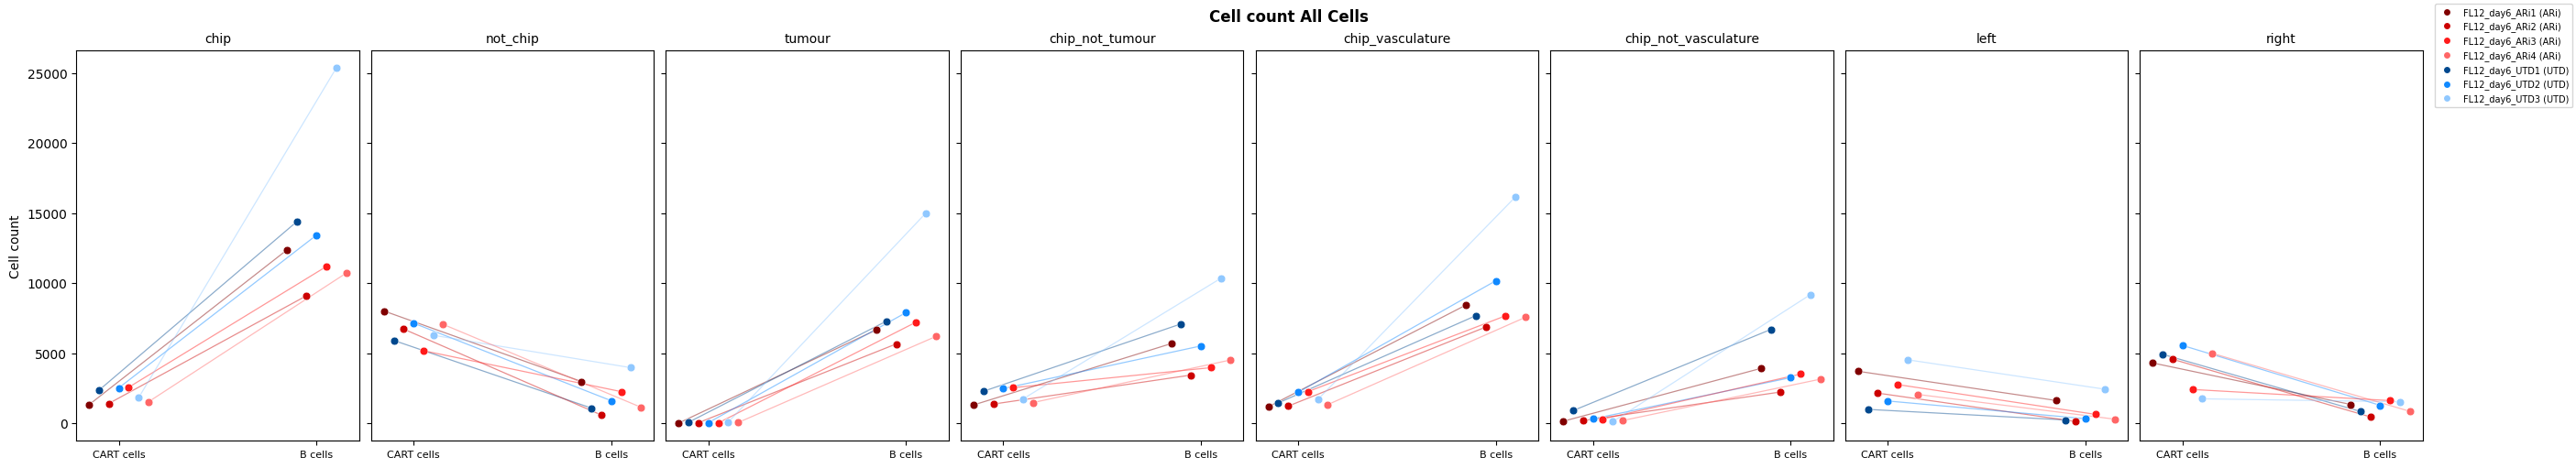

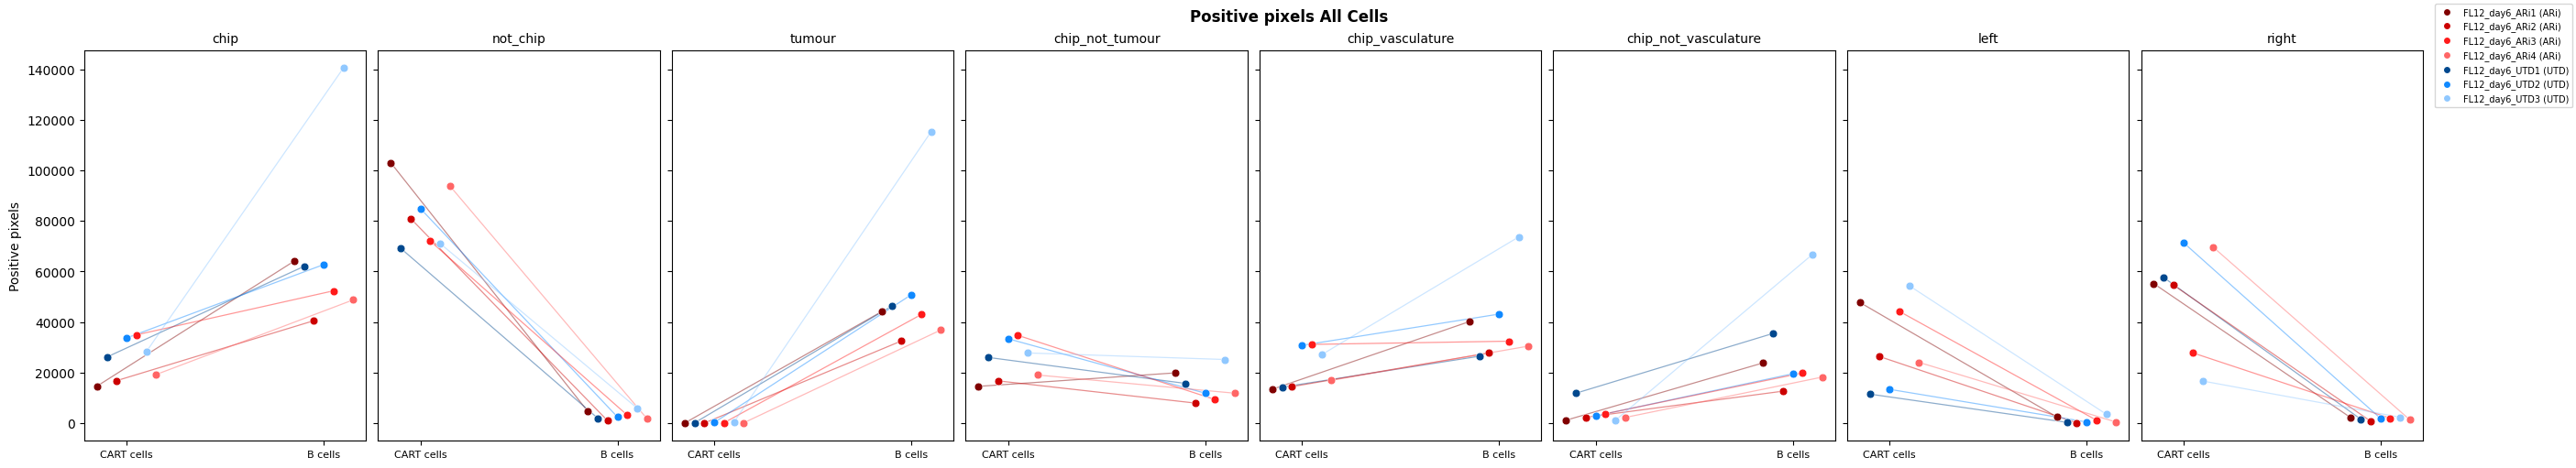

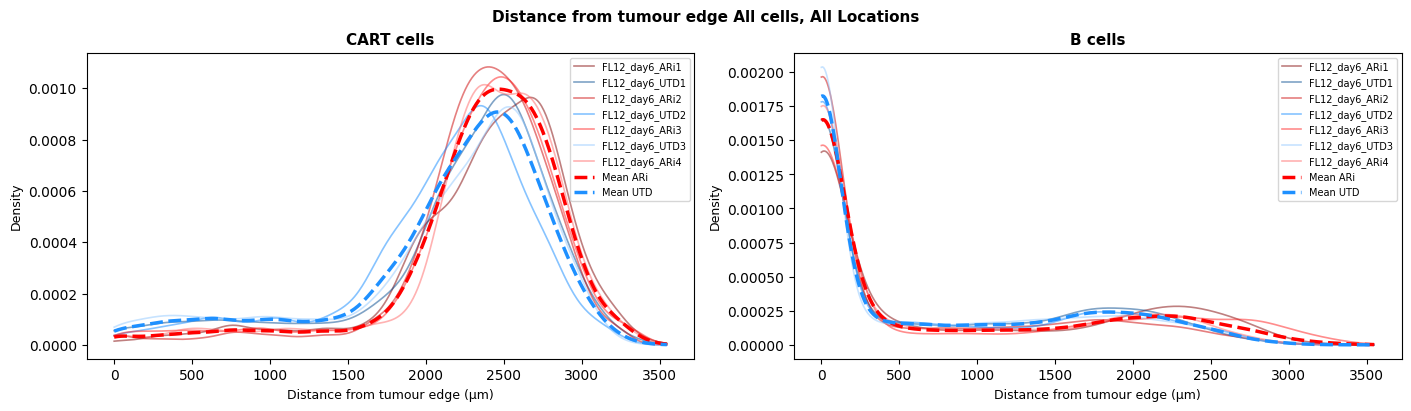

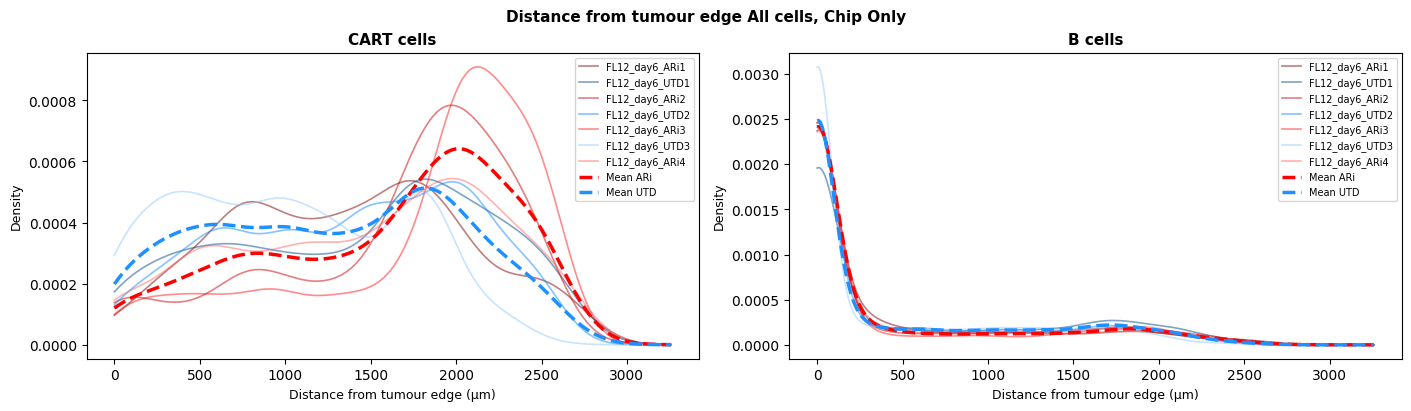

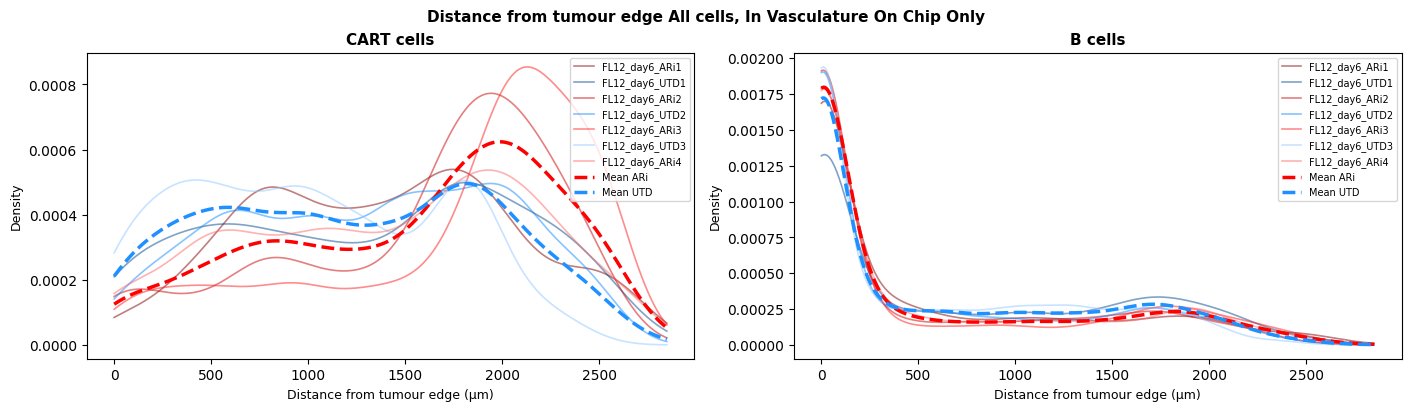

In [21]:
# 2) Define a palette for each condition
CONDITION_PALETTE = {
    "ARi_day6": "#ff0000",       # red
    "ARi_day7": "#ff8800",       # orange
    "UTD_day6": "#1e90ff",       # blue
    "UTD_day7": "#00cc88",       # teal
}
plot_swarmplots(all_results[(all_results["patient"]=="fl12") & (all_results["day"]=="6") ], save_title="fl12_d6", title_suffix = " All Cells")

plot_distance_kde(all_distances[(all_distances["patient"]=="fl12") & (all_distances["day"]=="6") ], save_title="fl12_d6_all_cells", title_suffix = " All cells, All Locations")
plot_distance_kde(all_distances[(all_distances["patient"]=="fl12") & (all_distances["day"]=="6") & (all_distances["in_chip"]== True) ], save_title="fl12_d6_cells_in_chip", title_suffix = " All cells, Chip Only")
plot_distance_kde(all_distances[(all_distances["patient"]=="fl12") & (all_distances["day"]=="6") & (all_distances["in_chip_vasculature"] == True) & (all_distances["in_chip"]== True) ], save_title="fl12_d6_cells_in_chip_AND_in_vasculature", title_suffix = " All cells, In Vasculature On Chip Only")

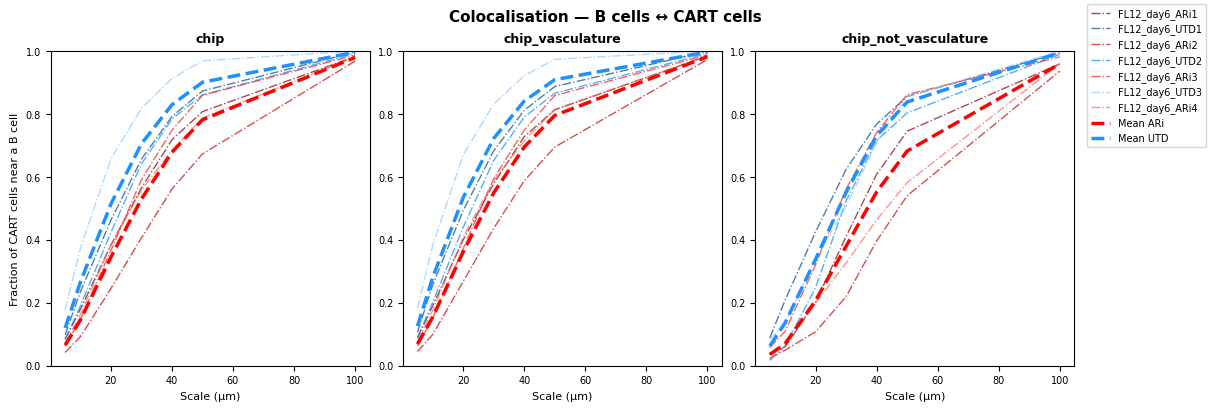

In [22]:
COLOC_REGIONS = ["chip", "chip_not_vasculature", "chip_vasculature"]

# Show just CART_near_B
plot_colocalisation(coloc_df[(coloc_df["day"] == "6") & (coloc_df["patient"] == "fl12")], methods=["CART_near_B"], save_title="d6_fl12_cart_near_B", plot_regions=["chip", "chip_vasculature", "chip_not_vasculature"])

# Show just B_near_CART
# plot_colocalisation(_coloc_sub, methods=["B_near_CART"], plot_regions=COLOC_REGIONS)

# Show just coarse Pearson
# plot_colocalisation(_coloc_sub, methods=["coarse_pearson"], plot_regions=COLOC_REGIONS)

# Show all three methods at once
# plot_colocalisation(_coloc_sub, plot_regions=COLOC_REGIONS)
